In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error, make_scorer
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

pd.set_option("display.max_columns", None)

arquivos = list(Path(".").rglob("mecaniqa_dataset.csv"))
if not arquivos:
    raise FileNotFoundError(
        "mecaniqa_dataset.csv não encontrado. Execute o notebook na pasta do projeto."
    )

caminho = arquivos[0]
print("Dataset:", caminho)
df = pd.read_csv(caminho)

col_data = next((coluna for coluna in df.columns if coluna.lower() in {"data", "date", "data_servico", "data_atendimento"}), None)
if col_data is None:
    raise ValueError("Não foi possível identificar a coluna de data.")

alvos = ["Trocas_Oleo", "Manutencao_Motor"]
if not set(alvos).issubset(df.columns):
    raise ValueError(f"Colunas alvo esperadas não encontradas: {alvos}")

df[col_data] = pd.to_datetime(df[col_data], dayfirst=True, errors="coerce")
df = df.dropna(subset=[col_data]).sort_values(col_data).set_index(col_data)

for alvo in alvos:
    df[f"{alvo}_lag_1"] = df[alvo].shift(1)
    df[f"{alvo}_lag_7"] = df[alvo].shift(7)
    df[f"{alvo}_lag_30"] = df[alvo].shift(30)
    df[f"{alvo}_media_7"] = df[alvo].shift(1).rolling(7).mean()
    df[f"{alvo}_media_30"] = df[alvo].shift(1).rolling(30).mean()

df["dia_semana"] = df.index.dayofweek
df["mes"] = df.index.month
df["dia_mes"] = df.index.day

features = [
    "Trocas_Oleo_lag_1", "Trocas_Oleo_lag_7", "Trocas_Oleo_lag_30",
    "Trocas_Oleo_media_7", "Trocas_Oleo_media_30",
    "Manutencao_Motor_lag_1", "Manutencao_Motor_lag_7", "Manutencao_Motor_lag_30",
    "Manutencao_Motor_media_7", "Manutencao_Motor_media_30",
    "dia_semana", "mes", "dia_mes"
]
df_final = df.dropna(subset=features + alvos).copy()
print(f"Registros após preparar as features: {len(df_final)}")
display(df_final[alvos + features].head())

Dataset: mecaniqa_dataset.csv
Registros após preparar as features: 203


,Trocas_Oleo,Manutencao_Motor,Trocas_Oleo_lag_1,Trocas_Oleo_lag_7,Trocas_Oleo_lag_30,Trocas_Oleo_media_7,Trocas_Oleo_media_30,Manutencao_Motor_lag_1,Manutencao_Motor_lag_7,Manutencao_Motor_lag_30,Manutencao_Motor_media_7,Manutencao_Motor_media_30,dia_semana,mes,dia_mes
Data,,,,,,,,,,,,,,,
2024-03-07,13.0,5.0,19.0,12.0,11.0,22.285714,21.033333,11.0,7.0,2.0,9.142857,8.333333,3,3,7
2024-03-08,27.0,7.0,13.0,12.0,21.0,22.428571,21.100000,5.0,1.0,13.0,8.857143,8.433333,4,3,8
2024-03-09,6.0,-2.0,27.0,28.0,33.0,24.571429,21.300000,7.0,13.0,13.0,9.714286,8.233333,5,3,9
2024-03-10,8.0,4.0,6.0,32.0,25.0,21.428571,20.400000,-2.0,10.0,14.0,7.571429,7.733333,6,3,10
2024-03-11,23.0,9.0,8.0,21.0,19.0,18.000000,19.833333,4.0,7.0,6.0,6.714286,7.400000,0,3,11


In [16]:
corte = int(len(df_final) * 0.80)
treino = df_final.iloc[:corte].copy()
teste = df_final.iloc[corte:].copy()

X_treino = treino[features]
X_teste = teste[features]

assert treino.index.max() < teste.index.min(), "A ordem temporal entre treino e teste não foi respeitada."
print(f"Treino: {len(treino)} registros | {treino.index.min().date()} até {treino.index.max().date()}")
print(f"Teste : {len(teste)} registros | {teste.index.min().date()} até {teste.index.max().date()}")
print("Divisão cronológica validada.")

def mape_percentual(y_real, y_previsto):
    y_real = np.asarray(y_real, dtype=float)
    y_previsto = np.asarray(y_previsto, dtype=float)
    if y_real.shape != y_previsto.shape:
        raise ValueError("y_real e y_previsto precisam ter o mesmo tamanho.")

    mascara = np.isfinite(y_real) & (y_real != 0) & np.isfinite(y_previsto)
    if not mascara.any():
        raise ValueError("O MAPE não pode ser calculado: não há valores reais finitos e diferentes de zero.")

    return mean_absolute_percentage_error(
        y_real[mascara], y_previsto[mascara]
    ) * 100

resultados_baseline = []
previsoes_baseline = {}
for alvo in alvos:
    modelo_base = RandomForestRegressor(random_state=42)
    modelo_base.fit(X_treino, treino[alvo])
    previsoes = modelo_base.predict(X_teste)
    previsoes_baseline[alvo] = previsoes
    resultados_baseline.append({"Série": alvo, "MAPE padrão (%)": mape_percentual(teste[alvo], previsoes)})

baseline_df = pd.DataFrame(resultados_baseline)
display(baseline_df.round(2))

Treino: 162 registros | 2024-03-07 até 2025-09-07
Teste : 41 registros | 2025-09-08 até 2025-12-12
Divisão cronológica validada.


,Série,MAPE padrão (%)
0,Trocas_Oleo,22.22
1,Manutencao_Motor,29.03


In [17]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10],
    "min_samples_split": [2, 5, 10]
}

def mape_para_scorer(y_real, y_previsto):
    return mape_percentual(y_real, y_previsto)

scorer_mape = make_scorer(mape_para_scorer, greater_is_better=False)

resultados_busca = []
melhores_modelos = {}
previsoes_otimizadas = {}

for alvo in alvos:
    busca = GridSearchCV(
        estimator=RandomForestRegressor(random_state=42),
        param_grid=param_grid,
        scoring=scorer_mape,
        cv=TimeSeriesSplit(n_splits=5),
        n_jobs=-1,
        refit=True,
        return_train_score=False
    )
    busca.fit(X_treino, treino[alvo])
    melhores_modelos[alvo] = busca.best_estimator_

    previsoes = busca.best_estimator_.predict(X_teste)
    previsoes_otimizadas[alvo] = previsoes
    y_teste = teste[alvo]
    rmse_otimizado = np.sqrt(np.mean((y_teste.to_numpy() - previsoes) ** 2))
    mape_otimizado = mape_percentual(y_teste, previsoes)

    resultados_busca.append({
        "Série": alvo,
        "Melhores parâmetros": busca.best_params_,
        "RMSE otimizado": rmse_otimizado,
        "MAPE otimizado (%)": mape_otimizado,
        "MAPE médio na validação (%)": -busca.best_score_
    })

    print(f"\nAlvo: {alvo}")
    print(f"best_params_: {busca.best_params_}")
    print(f"Novo RMSE: {rmse_otimizado:.4f}")
    print(f"Novo MAPE: {mape_otimizado:.2f}%")

busca_df = pd.DataFrame(resultados_busca)
display(busca_df.round(2))


Alvo: Trocas_Oleo
best_params_: {'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 50}
Novo RMSE: 7.1000
Novo MAPE: 20.77%

Alvo: Manutencao_Motor
best_params_: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}
Novo RMSE: 3.1788
Novo MAPE: 28.69%


,Série,Melhores parâmetros,RMSE otimizado,MAPE otimizado (%),MAPE médio na validação (%)
0,Trocas_Oleo,"{'max_depth': 3, 'min_samples_split': 5, 'n_es...",7.10,20.77,28.91
1,Manutencao_Motor,"{'max_depth': 3, 'min_samples_split': 2, 'n_es...",3.18,28.69,39.28


In [18]:
comparacoes = []
for alvo in alvos:
    mape_base = mape_percentual(teste[alvo], previsoes_baseline[alvo])
    mape_otimizado = mape_percentual(teste[alvo], previsoes_otimizadas[alvo])
    reducao = ((mape_base - mape_otimizado) / mape_base * 100) if mape_base != 0 else np.nan
    comparacoes.append({
        "Série": alvo,
        "MAPE padrão (%)": mape_base,
        "MAPE otimizado (%)": mape_otimizado,
        "Redução do erro (%)": reducao
    })

comparacao_df = pd.DataFrame(comparacoes)
print("Comparação no conjunto de teste temporal:")
display(comparacao_df.round(2))

for _, linha in comparacao_df.iterrows():
    status = "reduziu" if linha["Redução do erro (%)"] > 0 else "não reduziu"
    print(
        f"{linha['Série']}: MAPE padrão = {linha['MAPE padrão (%)']:.2f}% | "
        f"MAPE otimizado = {linha['MAPE otimizado (%)']:.2f}% | "
        f"redução = {linha['Redução do erro (%)']:.2f}% ({status})."
    )

Comparação no conjunto de teste temporal:


,Série,MAPE padrão (%),MAPE otimizado (%),Redução do erro (%)
0,Trocas_Oleo,22.22,20.77,6.53
1,Manutencao_Motor,29.03,28.69,1.17


Trocas_Oleo: MAPE padrão = 22.22% | MAPE otimizado = 20.77% | redução = 6.53% (reduziu).
Manutencao_Motor: MAPE padrão = 29.03% | MAPE otimizado = 28.69% | redução = 1.17% (reduziu).


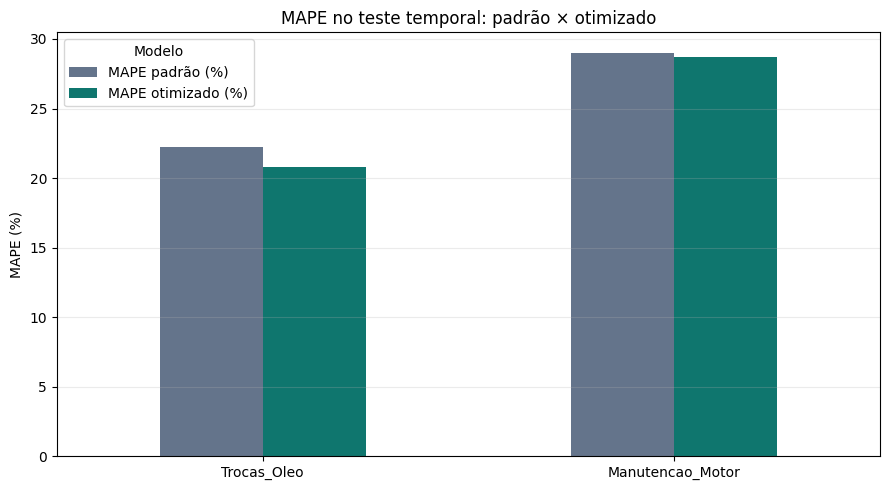

In [19]:
ax = comparacao_df.set_index("Série")[["MAPE padrão (%)", "MAPE otimizado (%)"]].plot(
    kind="bar", figsize=(9, 5), color=["#64748b", "#0f766e"]
)
ax.set_title("MAPE no teste temporal: padrão × otimizado")
ax.set_ylabel("MAPE (%)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Modelo")
plt.tight_layout()
plt.show()